# 🧠 Deep Averaging Network (DAN) Implementation - Neural Model

This notebook implements a **Deep Averaging Network (DAN)** with PyTorch for information retrieval on the TREC-COVID dataset.

## Objectives
- Load the TREC-COVID dataset
- Initialize embeddings with pre-trained BioWord2Vec
- Implement a DAN with Bi-Encoder (Siamese) architecture
- Train the model with TripletMarginLoss
- Use general-purpose functions for evaluation
- Evaluate performance with NDCG@10 and compare with baselines


## 📦 1. Imports and Configuration


In [ ]:
# Required imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from gensim.models import KeyedVectors
from beir.datasets.data_loader import GenericDataLoader
from collections import Counter
import random

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

# PyTorch configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device used: {device}")

# NLTK imports (separated to avoid circular import conflicts)
# If you get an error, restart the Jupyter kernel and re-run this cell
print("Loading NLTK...")
try:
    # Import submodules first
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    
    # Then import nltk for downloads
    import nltk
    
    # Download required NLTK data
    try:
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("  Downloading 'punkt'...")
        nltk.download('punkt', quiet=True)
    
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        print("  Downloading 'stopwords'...")
        nltk.download('stopwords', quiet=True)
    
    print("✓ NLTK loaded successfully")
except AttributeError as e:
    print("⚠️ Circular import error detected!")
    print("🔧 SOLUTION: Restart the Jupyter kernel (Kernel -> Restart Kernel)")
    print("   then re-run this cell.")
    raise
except Exception as e:
    print(f"⚠️ Error importing NLTK: {e}")
    print("🔧 SOLUTION: Restart the Jupyter kernel and re-run this cell")
    raise

print("✓ Imports completed")


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\beir\datasets\data_loader.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


✓ Device utilisé: cpu
Chargement de NLTK...
✓ NLTK chargé avec succès
✓ Imports terminés


## 📂 2. Data Loading


In [ ]:
# Path to the TREC-COVID dataset
data_path = "data/trec-covid/trec-covid"

# Check that the dataset exists
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}. Run download.py first")

print(f"Loading dataset from: {data_path}")


Chargement du dataset depuis: data/trec-covid/trec-covid


In [ ]:
# Load data with BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus loaded: {len(corpus)} documents")
print(f"✓ Queries loaded: {len(queries)} queries")
print(f"✓ Qrels loaded: {len(qrels)} relevance judgments")


100%|██████████| 171332/171332 [00:01<00:00, 123657.46it/s]

✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


## 🔧 3. Data Preparation and Vocabulary Creation


### 3.1. Tokenization and Vocabulary Construction


In [ ]:
# Load stop words
stop_words = set(stopwords.words('english'))

# Tokenize all documents and queries to build the vocabulary
print("Tokenizing documents and queries...")
all_tokens = []

# Tokenize documents
for doc_id, doc in corpus.items():
    full_text = f"{doc['title']} {doc['text']}"
    tokens = word_tokenize(full_text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    all_tokens.extend(tokens)

# Tokenize queries
for query_id, query_text in queries.items():
    tokens = word_tokenize(query_text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    all_tokens.extend(tokens)

# Build vocabulary (words that appear at least 2 times)
word_counts = Counter(all_tokens)
# Filter words that appear at least 2 times
filtered_words = [word for word, count in word_counts.items() if count >= 2]

# Build vocabulary with sequential indices
vocab = {}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
# Add other words with indices starting from 2
for idx, word in enumerate(filtered_words):
    vocab[word] = idx + 2

vocab_size = len(vocab)

print(f"✓ Vocabulary created: {vocab_size} words")
print(f"  - Unique tokens: {len(word_counts)}")
print(f"  - Words with at least 2 occurrences: {len(filtered_words)}")
print(f"  - Indices used: 0 to {vocab_size - 1}")


Tokenisation des documents et requêtes...
✓ Vocabulaire créé: 105773 mots
  - Tokens uniques: 168080
  - Mots avec au moins 2 occurrences: 105771
  - Indices utilisés: 0 à 105772


### 3.2. Loading BioWord2Vec and Initializing the Embedding Matrix


In [ ]:
# Load the pre-trained BioWord2Vec model
model_dir = "models"
model_name = "BioWordVec_PubMed_MIMICIII_d200_sub1500000.vec.bin"
model_path = os.path.join(model_dir, model_name)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"BioWord2Vec model not found at {model_path}. Run bioword2vec.ipynb first")

print("Loading BioWord2Vec model...")
bioword2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

embedding_dim = bioword2vec_model.vector_size
# vocab_size has already been defined in the previous cell
# Verify that it matches the vocabulary size
assert vocab_size == len(vocab), f"Inconsistency: vocab_size={vocab_size} but len(vocab)={len(vocab)}"

print(f"✓ BioWord2Vec model loaded")
print(f"  - Embedding dimension: {embedding_dim}")
print(f"  - Vocabulary size: {vocab_size}")
print(f"  - Indices used: 0 to {vocab_size - 1}")


Chargement du modèle BioWord2Vec...
✓ Modèle BioWord2Vec chargé
  - Dimension des embeddings: 200
  - Taille du vocabulaire: 105773
  - Indices utilisés: 0 à 105772


In [ ]:
# Initialize the embedding matrix with BioWord2Vec
print("Initializing embedding matrix...")

# Check vocabulary size
vocab_size_actual = len(vocab)
print(f"  - Actual vocabulary size: {vocab_size_actual}")
print(f"  - Expected size: {vocab_size}")

# Ensure vocab_size matches the actual size
if vocab_size != vocab_size_actual:
    print(f"  ⚠️ Correction: vocab_size adjusted from {vocab_size} to {vocab_size_actual}")
    vocab_size = vocab_size_actual

# Create the embedding matrix with the correct size
embedding_matrix = np.random.normal(0, 0.01, (vocab_size, embedding_dim))

# Fill with BioWord2Vec embeddings
words_found = 0
words_not_found = 0

for word, idx in vocab.items():
    # Verify that the index is valid
    if idx >= vocab_size:
        print(f"  ⚠️ Index out of bounds: {word} -> {idx} (max: {vocab_size-1})")
        continue
        
    if word == '<PAD>':
        # Padding to zero
        embedding_matrix[idx] = np.zeros(embedding_dim)
    elif word == '<UNK>':
        # UNK initialized randomly (already done)
        pass
    elif word in bioword2vec_model:
        embedding_matrix[idx] = bioword2vec_model[word]
        words_found += 1
    else:
        words_not_found += 1

print(f"✓ Embedding matrix initialized")
print(f"  - Matrix shape: {embedding_matrix.shape}")
print(f"  - Words found in BioWord2Vec: {words_found}")
print(f"  - Words not found (randomly initialized): {words_not_found}")
if words_found + words_not_found > 0:
    print(f"  - Coverage rate: {words_found / (words_found + words_not_found) * 100:.2f}%")


Initialisation de la matrice d'embeddings...
  - Taille réelle du vocabulaire: 105773
  - Taille attendue: 105773
✓ Matrice d'embeddings initialisée
  - Forme de la matrice: (105773, 200)
  - Mots trouvés dans BioWord2Vec: 84794
  - Mots non trouvés (initialisés aléatoirement): 20977
  - Taux de couverture: 80.17%


## 🎯 4. DAN Model Architecture


### 4.1. DAN_Encoder Class

The **Deep Averaging Network (DAN)**:
- Takes a sequence of words (query or document)
- Converts each word into an embedding
- Averages the embeddings (ignoring padding)
- Passes through an MLP (Multi-Layer Perceptron) to obtain a dense representation


In [ ]:
class DAN_Encoder(nn.Module):
    """
    Deep Averaging Network Encoder
    Architecture: Embedding -> Average -> MLP -> Output
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim=300, output_dim=200, dropout=0.3, embedding_matrix=None):
        super(DAN_Encoder, self).__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Initialize with BioWord2Vec if provided
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
            # Don't train padding embeddings
            self.embedding.weight.data[0] = torch.zeros(embedding_dim)
        
        # MLP (Multi-Layer Perceptron)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch_size, seq_len) with word indices
        Returns:
            Tensor of shape (batch_size, output_dim) with dense representation
        """
        # Embeddings: (batch_size, seq_len, embedding_dim)
        embeddings = self.embedding(x)
        
        # Mask to ignore padding (0)
        mask = (x != 0).float().unsqueeze(-1)  # (batch_size, seq_len, 1)
        
        # Average embeddings (ignoring padding)
        masked_embeddings = embeddings * mask
        sum_embeddings = masked_embeddings.sum(dim=1)  # (batch_size, embedding_dim)
        word_counts = mask.sum(dim=1).clamp(min=1)  # (batch_size, 1) - at least 1 to avoid division by 0
        avg_embeddings = sum_embeddings / word_counts  # (batch_size, embedding_dim)
        
        # Pass through MLP
        output = self.mlp(avg_embeddings)  # (batch_size, output_dim)
        
        return output

# Create the model
model = DAN_Encoder(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=300,
    output_dim=200,
    dropout=0.3,
    embedding_matrix=embedding_matrix
).to(device)

print(f"✓ DAN model created")
print(f"  - Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  - Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


✓ Modèle DAN créé
  - Paramètres totaux: 21,275,100
  - Paramètres entraînables: 21,275,100


### 4.2. Utility Functions for Tokenization


In [ ]:
def text_to_indices(text, vocab, max_length=100):
    """
    Converts a text into a sequence of indices for the model.
    Args:
        text: Text to tokenize
        vocab: Vocabulary dictionary {word: idx}
        max_length: Maximum sequence length
    Returns:
        List of indices
    """
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Truncate or pad to max_length
    if len(indices) > max_length:
        indices = indices[:max_length]
    else:
        indices = indices + [vocab['<PAD>']] * (max_length - len(indices))
    
    return indices

# Test
test_text = "what is the origin of COVID-19"
test_indices = text_to_indices(test_text, vocab)
print(f"✓ Tokenization test:")
print(f"  Text: '{test_text}'")
print(f"  Indices: {test_indices[:10]}... (length: {len(test_indices)})")


✓ Test de tokenisation:
  Texte: 'what is the origin of COVID-19'
  Indices: [760, 0, 0, 0, 0, 0, 0, 0, 0, 0]... (longueur: 100)


## 📊 5. Triplet Dataset Creation


### 5.1. TripletsDataset Class

For training with TripletMarginLoss, we need triplets:
- **Anchor**: Query
- **Positive**: Relevant document (score > 0 in Qrels)
- **Negative**: Non-relevant document (score = 0 or random document)


In [ ]:
class TripletsDataset(Dataset):
    """
    Dataset to generate triplets (Query, Relevant_Document, Non_Relevant_Document)
    """
    def __init__(self, queries, corpus, qrels, vocab, max_length=100):
        self.queries = queries
        self.corpus = corpus
        self.qrels = qrels
        self.vocab = vocab
        self.max_length = max_length
        
        # Prepare triplets
        self.triplets = []
        self._prepare_triplets()
    
    def _prepare_triplets(self):
        """Prepares all training triplets"""
        print("Preparing training triplets...")
        
        # Get all doc_ids
        all_doc_ids = list(self.corpus.keys())
        
        for query_id, query_text in self.queries.items():
            query_qrels = self.qrels.get(query_id, {})
            
            # Relevant documents (score > 0)
            positive_docs = [doc_id for doc_id, score in query_qrels.items() if score > 0]
            
            if len(positive_docs) == 0:
                continue  # Skip if no relevant documents
            
            # Non-relevant documents (score = 0 or random documents)
            negative_docs = [doc_id for doc_id, score in query_qrels.items() if score == 0]
            
            # If not enough negatives in Qrels, add random documents
            if len(negative_docs) < len(positive_docs):
                # Add random documents that are not in Qrels
                available_negatives = [doc_id for doc_id in all_doc_ids if doc_id not in query_qrels]
                negative_docs.extend(random.sample(available_negatives, 
                                                 min(len(available_negatives), 
                                                     len(positive_docs) - len(negative_docs))))
            
            # Create triplets
            for pos_doc_id in positive_docs:
                # Choose a random negative document
                neg_doc_id = random.choice(negative_docs) if negative_docs else random.choice(all_doc_ids)
                
                self.triplets.append((query_id, pos_doc_id, neg_doc_id))
        
        print(f"✓ {len(self.triplets)} triplets created")
    
    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, idx):
        query_id, pos_doc_id, neg_doc_id = self.triplets[idx]
        
        # Tokenize and convert to indices
        query_text = self.queries[query_id]
        pos_doc_text = f"{self.corpus[pos_doc_id]['title']} {self.corpus[pos_doc_id]['text']}"
        neg_doc_text = f"{self.corpus[neg_doc_id]['title']} {self.corpus[neg_doc_id]['text']}"
        
        query_indices = text_to_indices(query_text, self.vocab, self.max_length)
        pos_indices = text_to_indices(pos_doc_text, self.vocab, self.max_length)
        neg_indices = text_to_indices(neg_doc_text, self.vocab, self.max_length)
        
        return (
            torch.tensor(query_indices, dtype=torch.long),
            torch.tensor(pos_indices, dtype=torch.long),
            torch.tensor(neg_indices, dtype=torch.long)
        )

# Create the dataset
train_dataset = TripletsDataset(queries, corpus, qrels, vocab, max_length=100)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"✓ Dataset created: {len(train_dataset)} triplets")
print(f"✓ DataLoader created: {len(train_loader)} batches (batch_size=32)")


Préparation des triplets d'entraînement...
✓ 24673 triplets créés
✓ Dataset créé: 24673 triplets
✓ DataLoader créé: 772 batches (batch_size=32)


## 🚀 6. Model Training


### 6.1. Training Configuration


In [ ]:
# Loss function: TripletMarginLoss with cosine distance
# The loss encourages the anchor to be closer to the positive than to the negative
criterion = nn.TripletMarginLoss(margin=1.0, p=2)  # Euclidean distance

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
num_epochs = 5

print(f"✓ Training configuration:")
print(f"  - Loss: TripletMarginLoss (margin=1.0)")
print(f"  - Optimizer: Adam (lr=0.001)")
print(f"  - Epochs: {num_epochs}")
print(f"  - Batch size: 32")


✓ Configuration de l'entraînement:
  - Loss: TripletMarginLoss (margin=1.0)
  - Optimizer: Adam (lr=0.001)
  - Époques: 5
  - Batch size: 32


### 6.2. Training Loop


In [ ]:
# Training
print("Starting training...\n")
model.train()

losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_idx, (query_batch, pos_batch, neg_batch) in enumerate(train_loader):
        # Move to device
        query_batch = query_batch.to(device)
        pos_batch = pos_batch.to(device)
        neg_batch = neg_batch.to(device)
        
        # Forward pass
        query_emb = model(query_batch)  # (batch_size, output_dim)
        pos_emb = model(pos_batch)      # (batch_size, output_dim)
        neg_emb = model(neg_batch)      # (batch_size, output_dim)
        
        # Calculate loss
        loss = criterion(query_emb, pos_emb, neg_emb)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} completed - Average loss: {avg_loss:.4f}\n")

print("✓ Training completed")


Début de l'entraînement...

  Epoch 1/5, Batch 100/772, Loss: 0.7287
  Epoch 1/5, Batch 200/772, Loss: 0.3763
  Epoch 1/5, Batch 300/772, Loss: 0.5073
  Epoch 1/5, Batch 400/772, Loss: 0.2970
  Epoch 1/5, Batch 500/772, Loss: 0.6627
  Epoch 1/5, Batch 600/772, Loss: 0.2890
  Epoch 1/5, Batch 700/772, Loss: 0.5486
Epoch 1/5 terminée - Loss moyenne: 0.5281

  Epoch 2/5, Batch 100/772, Loss: 0.3553
  Epoch 2/5, Batch 200/772, Loss: 0.2362
  Epoch 2/5, Batch 300/772, Loss: 0.2195
  Epoch 2/5, Batch 400/772, Loss: 0.4351
  Epoch 2/5, Batch 500/772, Loss: 0.4814
  Epoch 2/5, Batch 600/772, Loss: 0.5356
  Epoch 2/5, Batch 700/772, Loss: 0.1949
Epoch 2/5 terminée - Loss moyenne: 0.3213

  Epoch 3/5, Batch 100/772, Loss: 0.3463
  Epoch 3/5, Batch 200/772, Loss: 0.6083
  Epoch 3/5, Batch 300/772, Loss: 0.2403
  Epoch 3/5, Batch 400/772, Loss: 0.1960
  Epoch 3/5, Batch 500/772, Loss: 0.1847
  Epoch 3/5, Batch 600/772, Loss: 0.2145
  Epoch 3/5, Batch 700/772, Loss: 0.3851
Epoch 3/5 terminée - Loss

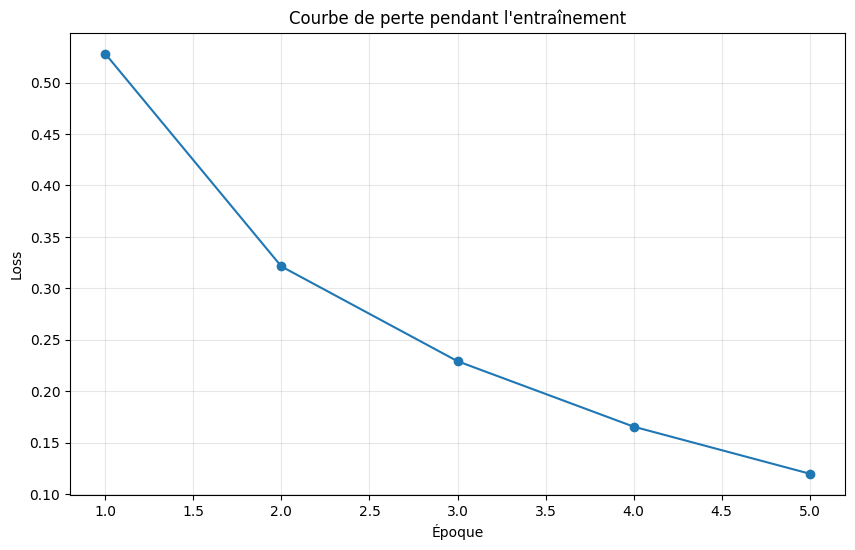

In [ ]:
# Visualize the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curve during training')
plt.grid(True, alpha=0.3)
plt.show()


## 🔍 7. Integration with Evaluation Functions


### 7.1. Creating DANVectorizer

⚠️ **Important**: This class must be compatible with `functions.search()` by having a `.transform(texts)` method that returns numpy vectors.


In [ ]:
class DANVectorizer:
    """
    DAN vectorizer compatible with the search() function from functions.py
    """
    def __init__(self, model, vocab, max_length=100):
        self.model = model
        self.vocab = vocab
        self.max_length = max_length
        self.model.eval()  # Evaluation mode
    
    def transform(self, texts):
        """
        Transforms a list of texts into vectors.
        Args:
            texts: List of strings
        Returns:
            Numpy array of shape (n_texts, output_dim)
        """
        vectors = []
        
        with torch.no_grad():  # No gradients needed for inference
            for text in texts:
                # Tokenize and convert to indices
                indices = text_to_indices(text, self.vocab, self.max_length)
                
                # Convert to tensor and add batch dimension
                input_tensor = torch.tensor([indices], dtype=torch.long).to(device)
                
                # Forward pass
                output = self.model(input_tensor)  # (1, output_dim)
                
                # Convert to numpy and remove batch dimension
                vector = output.cpu().numpy()[0]  # (output_dim,)
                vectors.append(vector)
        
        return np.array(vectors)

# Create the vectorizer
vectorizer = DANVectorizer(model, vocab, max_length=100)
print("✓ DANVectorizer created")


✓ DANVectorizer créé


### 7.2. Document Vector Creation


In [ ]:
# Create vectors for all documents
print("Creating document vectors with the trained DAN model...")
doc_vectors = []
doc_ids = []

for i, (doc_id, doc) in enumerate(corpus.items()):
    if (i + 1) % 10000 == 0:
        print(f"  Processing document {i+1}/{len(corpus)}...")
    
    # Combine title and text
    full_text = f"{doc['title']} {doc['text']}"
    
    # Use the vectorizer
    vector = vectorizer.transform([full_text])[0]
    doc_vectors.append(vector)
    doc_ids.append(doc_id)

doc_vectors = np.array(doc_vectors)

print(f"\n✓ Document vectors created")
print(f"  - Matrix shape: {doc_vectors.shape}")
print(f"  - Vector dimension: {doc_vectors.shape[1]}")


Création des vecteurs de documents avec le modèle DAN entraîné...
  Traitement document 10000/171332...
  Traitement document 20000/171332...
  Traitement document 30000/171332...
  Traitement document 40000/171332...
  Traitement document 50000/171332...
  Traitement document 60000/171332...
  Traitement document 70000/171332...
  Traitement document 80000/171332...
  Traitement document 90000/171332...
  Traitement document 100000/171332...
  Traitement document 110000/171332...
  Traitement document 120000/171332...
  Traitement document 130000/171332...
  Traitement document 140000/171332...
  Traitement document 150000/171332...
  Traitement document 160000/171332...
  Traitement document 170000/171332...

✓ Vecteurs de documents créés
  - Forme de la matrice: (171332, 200)
  - Dimension des vecteurs: 200


## 🔍 8. Relevant Document Search


### 8.1. Search Test on a Query


In [ ]:
# Test the search() function on the first query
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Test query: {test_query_id}")
print(f"Text: {test_query_text}\n")

# Use the general search() function
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents found:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Title: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc 75773gwg (score: 0.9772)
   Titre: Zoonotic origins of human coronavirus 2019 (HCoV-19 / SARS-CoV-2): why is this w...

2. Doc 12dcftwt (score: 0.9767)
   Titre: Possible Bat Origin of Severe Acute Respiratory Syndrome Coronavirus 2...

3. Doc kqqantwg (score: 0.9767)
   Titre: Possible Bat Origin of Severe Acute Respiratory Syndrome Coronavirus 2...

4. Doc 7t63xpvc (score: 0.9765)
   Titre: Animal origins of the severe acute respiratory syndrome coronavirus: insight fro...

5. Doc ab757i3f (score: 0.9696)
   Titre: Emergence of a Novel Coronavirus, Severe Acute Respiratory Syndrome Coronavirus ...

6. Doc d6by9p41 (score: 0.9689)
   Titre: Emergence of a Novel Coronavirus, Severe Acute Respiratory Syndrome Coronavirus ...

7. Doc ne5r4d4b (score: 0.9640)
   Titre: Origin and evolution of pathogenic coronaviruses...

8. Doc 04p52sal (score: 0.9633)
   Titre: The molecular biology of arteriviruses..

### 8.2. Comparison with Ideal Top 10


In [ ]:
# Compare model results with the ideal top 10
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Get model results
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Get ideal top 10
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARISON FOR QUERY {test_query_id}")
print(f"Text: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETURNED BY DAN MODEL:")
print("-" * 80)
for i, (doc_id, dan_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | DAN Score: {dan_score:.4f} | Actual relevance: {relevance}")
    print(f"    Title: {doc['title'][:70]}...")

print("\n✅ IDEAL TOP 10 (according to Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Relevance score: {relevance_score}")
    print(f"    Title: {doc['title'][:70]}...")

# Calculate NDCG@10 score for this query
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 NDCG@10 score for this query: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE DAN:
--------------------------------------------------------------------------------
 1. Doc 75773gwg | Score DAN: 0.9772 | Pertinence réelle: 2
    Titre: Zoonotic origins of human coronavirus 2019 (HCoV-19 / SARS-CoV-2): why...
 2. Doc 12dcftwt | Score DAN: 0.9767 | Pertinence réelle: 2
    Titre: Possible Bat Origin of Severe Acute Respiratory Syndrome Coronavirus 2...
 3. Doc kqqantwg | Score DAN: 0.9767 | Pertinence réelle: 2
    Titre: Possible Bat Origin of Severe Acute Respiratory Syndrome Coronavirus 2...
 4. Doc 7t63xpvc | Score DAN: 0.9765 | Pertinence réelle: 0
    Titre: Animal origins of the severe acute respiratory syndrome coronavirus: i...
 5. Doc ab757i3f | Score DAN: 0.9696 | Pertinence réelle: 1
    Titre: Emergence of a Novel Coronavirus, Severe Acute Respiratory Syndrome Co...
 6. Doc d6by9p41 | Score DAN: 0.9689 | Pertinence réelle: 2
    Titre: Emergence of a No

### 8.3. Search on All Queries


In [ ]:
# Search for relevant documents for all queries
print("Searching on all queries...")
print(f"(Processing {len(queries)} queries)\n")

# Dictionary to store all results: {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Processing query {i}/{len(queries)}...")
    
    # Search for top 10 documents with the general function
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Search completed for all queries")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 9. Evaluation with NDCG@10


In [ ]:
# Evaluate the model on all queries with evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.6630
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.2696
Number of queries: 50


### 9.1. Score Distribution


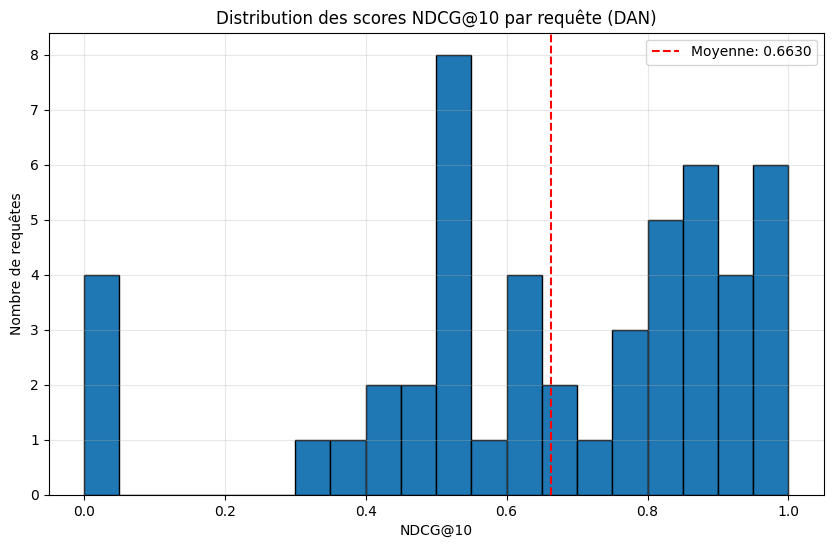

In [ ]:
# Display the distribution of NDCG@10 scores
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Number of queries')
plt.title('Distribution of NDCG@10 scores per query (DAN)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Mean: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 10. Results Analysis


In [ ]:
# Display the best and worst queries
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 best queries:")
print(ndcg_df.head())
print("\nTop 5 worst queries:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id   ndcg@10
11       12  1.000000
43       44  1.000000
1         2  0.996349
6         7  0.974743
0         1  0.972970

Top 5 pires requêtes:
   query_id   ndcg@10
30       31  0.333333
13       14  0.000000
9        10  0.000000
3         4  0.000000
33       34  0.000000


## 💾 11. Results Saving


In [ ]:
# Save results for comparison with other models
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Save NDCG scores
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/dan_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Save summary
summary = {
    "model": "DAN",
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids),
    "embedding_dim": embedding_dim,
    "hidden_dim": 300,
    "output_dim": 200,
    "num_epochs": num_epochs
}

with open(f"{results_dir}/dan_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Results saved in {results_dir}/")
print(f"  - dan_ndcg_scores.json")
print(f"  - dan_summary.json")


✓ Résultats sauvegardés dans results/
  - dan_ndcg_scores.json
  - dan_summary.json
